Import Dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix

use GU

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


Download Dataset

In [32]:
'''! pip install opendatasets'''

'! pip install opendatasets'

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
'''import opendatasets as od
import os

dataset_path = "/content/drive/MyDrive/datasets"

os.makedirs(dataset_path, exist_ok=True)

od.download(
    "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset",
    dataset_path
)'''

'import opendatasets as od\nimport os\n\ndataset_path = "/content/drive/MyDrive/datasets"\n\nos.makedirs(dataset_path, exist_ok=True)\n\nod.download(\n    "https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset",\n    dataset_path\n)'

In [35]:
#  check dataset path

import os

root = "/content/drive/MyDrive/datasets"

print(os.listdir(root))

['gopro-deblur', 'brain-tumor-mri-dataset']


In [36]:
dataset = "/content/drive/MyDrive/datasets/brain-tumor-mri-dataset"

print(os.listdir(dataset))

['Testing', 'Training']


reading thr Images  





In [37]:
import glob
import cv2
import os

tr_path = "/content/drive/MyDrive/datasets/brain-tumor-mri-dataset/Training"
tst_path = "/content/drive/MyDrive/datasets/brain-tumor-mri-dataset/Testing"

def load_images(folder_path):
    images = []
    labels = []
    for i in glob.iglob(folder_path + "/*/*.jpg"):
        img = cv2.imread(i)
        if img is None:
            print("Failed to load:", i)
            continue
        images.append(img)
        label = i.split(os.sep)[-2]   # parent folder name = class name
        labels.append(label)
    return images, labels

train_images, train_labels = load_images(tr_path)
test_images, test_labels = load_images(tst_path)

print("Total training images:", len(train_images))
print("Total testing images:", len(test_images))
print("Classes found:", set(train_labels))

Total training images: 5600
Total testing images: 1600
Classes found: {'meningioma', 'notumor', 'pituitary', 'glioma'}


In [38]:
sample = train_images[0]

print("Shape:", sample.shape)
print("Dtype:", sample.dtype)
print("Min/Max values:", sample.min(), sample.max())

print("\nTop-left 5x5 pixel patch:\n", sample[0:5, 0:5])

print("\nSingle pixel at (0,0):", sample[0, 0])

Shape: (512, 512, 3)
Dtype: uint8
Min/Max values: 0 255

Top-left 5x5 pixel patch:
 [[[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  [1 1 1]
  [1 1 1]]

 [[1 1 1]
  [1 1 1]
  [1 1 1]
  [1 1 1]
  [1 1 1]]]

Single pixel at (0,0): [0 0 0]


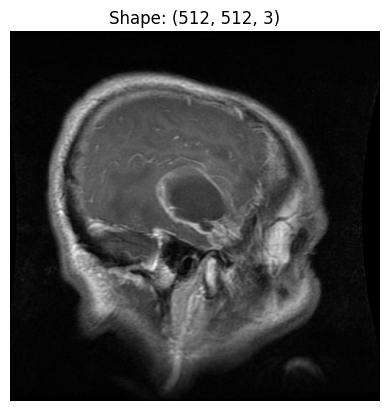

In [39]:
import matplotlib.pyplot as plt

sample_rgb = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)  # fix BGR->RGB for correct colors

plt.imshow(sample_rgb)
plt.title(f"Shape: {sample.shape}")
plt.axis("off")
plt.show()

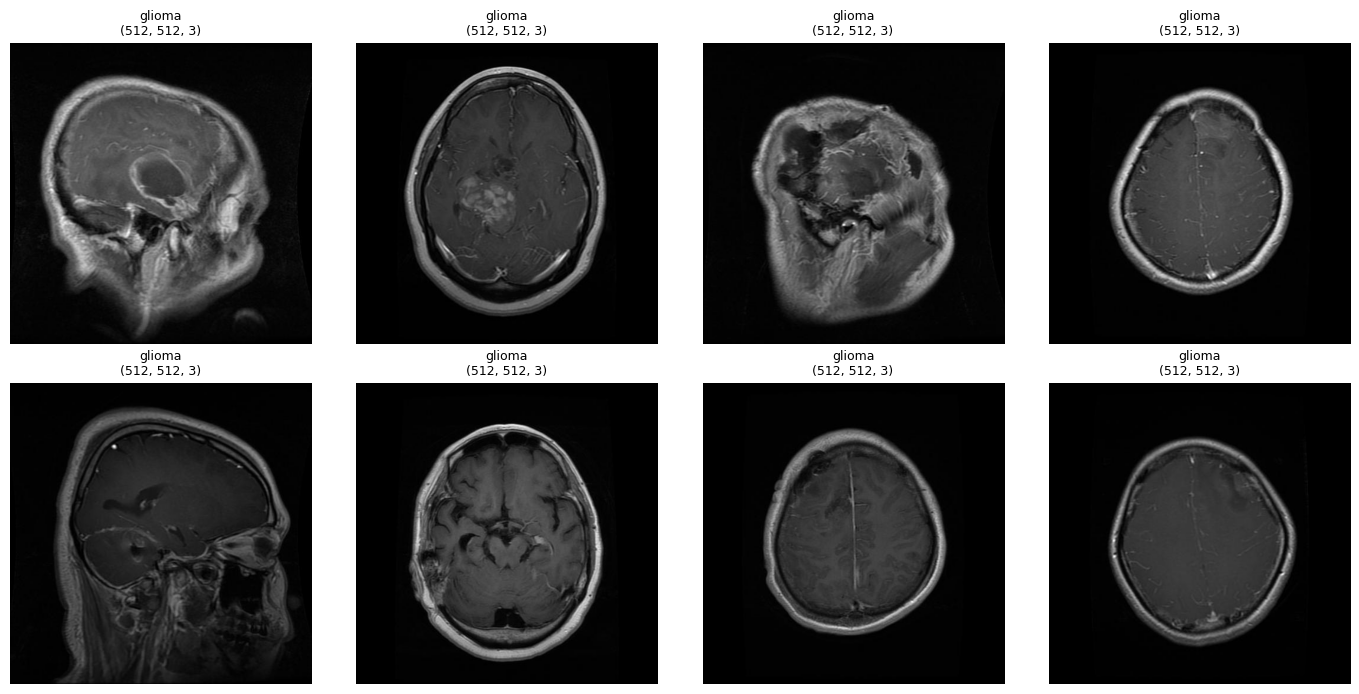

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for idx, ax in enumerate(axes.flat):
    img_rgb = cv2.cvtColor(train_images[idx], cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(f"{train_labels[idx]}\n{train_images[idx].shape}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [41]:
print(os.listdir(dataset))

['Testing', 'Training']


Custom PyTorch Dataset

In [42]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            for path in glob.glob(os.path.join(root_dir, cls, "*.jpg")):
                self.samples.append((path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")  # PIL keeps RGB order, unlike cv2
        if self.transform:
            img = self.transform(img)
        return img, label

Data Preprocessing

In [55]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

Datasets & DataLoaders

In [56]:
TEST_DIR = "/content/drive/MyDrive/datasets/brain-tumor-mri-dataset/Testing"

train_dataset = BrainTumorDataset(tr_path, transform=train_transform)
test_dataset = BrainTumorDataset(TEST_DIR, transform=test_transform)

print("Classes:", train_dataset.classes)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print("Batch shape:", images.shape)  # (32, 3, 224, 224) — note channel-first now

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train samples: 5600
Test samples: 1600
Batch shape: torch.Size([32, 3, 224, 224])


Create CNN Model

In [57]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 256),  # 224/2^4 = 14
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = BrainTumorCNN(num_classes=len(train_dataset.classes)).to(device)
print(model)

Using device: cuda
BrainTumorCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=256, out_featur

In [58]:
print(next(model.parameters()).device)

cuda:0


Loss function and optimizer

In [59]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

Training Loop

In [60]:
EPOCHS = 80

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f} | Acc: {100*correct/total:.2f}%")

Epoch 1/80 | Loss: 0.9982 | Acc: 57.50%
Epoch 2/80 | Loss: 0.7662 | Acc: 69.21%
Epoch 3/80 | Loss: 0.6645 | Acc: 73.71%
Epoch 4/80 | Loss: 0.5961 | Acc: 76.25%
Epoch 5/80 | Loss: 0.5373 | Acc: 78.91%
Epoch 6/80 | Loss: 0.5061 | Acc: 79.91%
Epoch 7/80 | Loss: 0.4930 | Acc: 80.93%
Epoch 8/80 | Loss: 0.4437 | Acc: 83.21%
Epoch 9/80 | Loss: 0.4079 | Acc: 84.27%
Epoch 10/80 | Loss: 0.3869 | Acc: 85.34%
Epoch 11/80 | Loss: 0.3686 | Acc: 86.12%
Epoch 12/80 | Loss: 0.3479 | Acc: 86.48%
Epoch 13/80 | Loss: 0.3478 | Acc: 86.75%
Epoch 14/80 | Loss: 0.3270 | Acc: 87.62%
Epoch 15/80 | Loss: 0.3149 | Acc: 88.23%
Epoch 16/80 | Loss: 0.2933 | Acc: 89.20%
Epoch 17/80 | Loss: 0.2881 | Acc: 89.02%
Epoch 18/80 | Loss: 0.2857 | Acc: 89.39%
Epoch 19/80 | Loss: 0.2815 | Acc: 89.68%
Epoch 20/80 | Loss: 0.2620 | Acc: 90.55%
Epoch 21/80 | Loss: 0.2517 | Acc: 89.96%
Epoch 22/80 | Loss: 0.2493 | Acc: 90.54%
Epoch 23/80 | Loss: 0.2353 | Acc: 91.55%
Epoch 24/80 | Loss: 0.2318 | Acc: 91.38%
Epoch 25/80 | Loss: 0.229

Evaluate Model

In [61]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

print("Train Accuracy:", 100 * correct / total)

Train Accuracy: 99.07142857142857


In [62]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, pred = torch.max(outputs, 1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 94.5625


Model Evaluation (Classification Report + Confusion Matrix)

              precision    recall  f1-score   support

      glioma       1.00      0.80      0.89       400
  meningioma       0.90      0.98      0.94       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.97      1.00      0.98       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.94      1600
weighted avg       0.95      0.95      0.94      1600



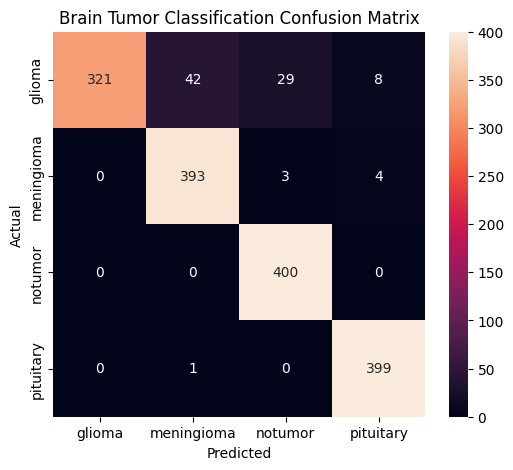

In [63]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


model.eval()

y_true = []
y_pred = []


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)


        y_true.extend(
            labels.cpu().numpy()
        )

        y_pred.extend(
            predictions.cpu().numpy()
        )


# Classification report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_dataset.classes
    )
)


# Confusion Matrix

cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Brain Tumor Classification Confusion Matrix")

plt.show()

Save Trained Model

In [64]:
model_path = "/content/drive/MyDrive/NeuroScan_AI_model.pth"


torch.save(
    {
        "model_state_dict": model.state_dict(),
        "classes": train_dataset.classes
    },
    model_path
)


print("Model saved successfully")

Model saved successfully


Load Model for Prediction

In [65]:
from PIL import Image


def predict_mri(image_path):

    model.eval()


    image = Image.open(image_path).convert("RGB")


    image_tensor = transform(image)


    image_tensor = image_tensor.unsqueeze(0)


    image_tensor = image_tensor.to(device)


    with torch.no_grad():

        output = model(image_tensor)


        probability = torch.softmax(
            output,
            dim=1
        )


        confidence, prediction = torch.max(
            probability,
            1
        )


    class_name = train_dataset.classes[
        prediction.item()
    ]


    confidence = confidence.item()*100


    return class_name, confidence

Test New MRI Image

Prediction: pituitary
Confidence: 100.00%


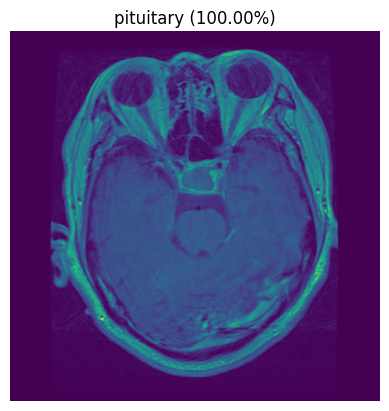

In [75]:
def predict_mri(image_path, model, class_names, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")

    image_tensor = test_transform(image).unsqueeze(0).to(device)  # use test_transform, not train_transform

    with torch.no_grad():
        output = model(image_tensor)
        probs = F.softmax(output, dim=1)
        confidence, pred = torch.max(probs, dim=1)

    predicted_class = class_names[pred.item()]
    confidence_pct = confidence.item() * 100

    return predicted_class, confidence_pct


# ---- Run prediction ----
image_path = "/content/drive/MyDrive/datasets/brain-tumor-mri-dataset/Testing/pituitary/Te-pi_157.jpg"

result, confidence = predict_mri(image_path, model, train_dataset.classes, device)

print("Prediction:", result)
print(f"Confidence: {confidence:.2f}%")

# ---- Show image with prediction ----
img = Image.open(image_path)

plt.imshow(img)
plt.title(f"{result} ({confidence:.2f}%)")
plt.axis("off")
plt.show()

Test New MRI Image(upload Image)

In [79]:
class_names = sorted(os.listdir(tr_path))
print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [80]:
def predict_mri(image_path, model, class_names, device):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    image_tensor = test_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probs = F.softmax(output, dim=1)
        confidence, pred = torch.max(probs, dim=1)

    predicted_class = class_names[pred.item()]
    confidence_pct = confidence.item() * 100
    return predicted_class, confidence_pct


def predict_and_show(image_path, model, class_names, device):
    result, confidence = predict_mri(image_path, model, class_names, device)

    img = Image.open(image_path)
    plt.imshow(img)
    plt.title(f"Predicted: {result} ({confidence:.2f}% confidence)")
    plt.axis("off")
    plt.show()

    return result, confidence

Saving Te-aug-me_22.jpg to Te-aug-me_22.jpg


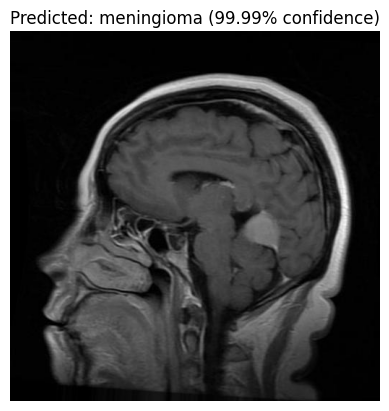

Prediction: meningioma
Confidence: 99.99%


In [83]:
from google.colab import files

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

result, confidence = predict_and_show(image_path, model, class_names, device)
print("Prediction:", result)
print(f"Confidence: {confidence:.2f}%")